# [LAB 05] 전체 모델 비교: 과적합 · Feature Importance · SHAP

- **목적**: 01~07 Channel 분류 모델을 한곳에서 비교
  - 과적합 여부 (학습곡선 기반 판정)
  - 유의미한 Feature Importance 수집 및 비교
  - SHAP 분석 및 Feature Importance 결과 비교
  - **시각화/채택 추천**: 어떤 모델을 대표로 시각화·운영에 쓰면 좋을지 제안
- **전제**: 01~07 노트북에서 각각 pkl 저장까지 실행해 둔 상태 (wholesale_*.pkl)

## 1. 라이브러리 및 데이터 로드 (00 스크립트와 동일)

In [2]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
)
from hossam import load_data
import matplotlib.pyplot as plt
import seaborn as sns

LAB05_DIR = Path('.').resolve()
RAW_COLS = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
log_cols = [f"log_{c}" for c in RAW_COLS]
FEATURE_COLS = log_cols + ["Region"]

def get_data_and_split():
    """노트북·00 스크립트와 동일한 전처리·split. scaler는 01에서 13컬럼(RAW+log+Region)으로 저장됨."""
    origin = load_data("wholesale_customers")
    df = origin[RAW_COLS + ["Region", "Channel"]].copy()
    # 01과 동일: df_log = RAW 6 + log 6 + Region (13컬럼)
    df_log = df[RAW_COLS].copy()
    for c in RAW_COLS:
        df_log[f"log_{c}"] = np.log1p(df_log[c])
    df_log["Region"] = df["Region"].values
    scaler_path = LAB05_DIR / "wholesale_scaler.pkl"
    if not scaler_path.exists():
        scaler = StandardScaler()
        X_all = scaler.fit_transform(df_log)
        # 학습용 7컬럼만 사용 (log 6 + Region)
        col_ix = [df_log.columns.get_loc(c) for c in FEATURE_COLS]
        X = X_all[:, col_ix]
    else:
        with open(scaler_path, "rb") as f:
            scaler = pickle.load(f)
        X_all = scaler.transform(df_log)
        col_ix = [df_log.columns.get_loc(c) for c in FEATURE_COLS]
        X = X_all[:, col_ix]
    y = (df["Channel"] - 1).values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=52, stratify=y
    )
    return X_train, X_test, y_train, y_test

def overfit_status_classification(final_train, final_cv, final_std):
    """분류용 과적합 판정 (LAB 09 / 00 스크립트와 동일)."""
    gap_ratio = final_train - final_cv
    var_ratio = final_std
    if final_train < 0.6 and final_cv < 0.6:
        return "⚠ 과소적합"
    if gap_ratio > 0.1:
        return "⚠ 과대적합"
    if gap_ratio <= 0.05 and var_ratio <= 0.05:
        return "✅ 일반화 양호"
    if var_ratio > 0.1:
        return "⚠ 데이터 부족"
    return "⚠ 판단유보"

X_train, X_test, y_train, y_test = get_data_and_split()
print("Train:", X_train.shape, "Test:", X_test.shape, "Features:", FEATURE_COLS)

이 데이터 세트는 도매 유통업체의 고객 정보를 담고 있습니다. 다양한 제품 카테고리에 대한 연간 지출액(mu, 화폐 단위)을 포함합니다. (출처: https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set)

컬럼명            의미                  설명
----------------  --------------------  --------------------------------------------------------------------------------------------
Channel           유통 채널             고객의 거래 채널을 나타냄. 주로 Horeca(호텔·레스토랑·카페) 또는 Retail(소매점) 구분에 사용됨
Region            지역                  고객이 속한 지리적 지역 구분 변수. 특정 국가 내의 권역 정보
Fresh             신선식품 구매액       육류, 채소, 과일 등 신선식품 카테고리에 대한 연간 구매 금액
Milk              유제품 구매액         우유, 치즈, 요거트 등 유제품 카테고리에 대한 연간 구매 금액
Grocery           식료품 구매액         가공식품, 일반 식료품 등 장기 보관 식품 카테고리 구매 금액
Frozen            냉동식품 구매액       냉동 육류, 냉동 가공식품 등 냉동식품 카테고리 구매 금액
Detergents_Paper  세제·종이류 구매액    세제, 화장지, 키친타월 등 생활 소모품 구매 금액
Delicassen        즉석·가공식품 구매액  즉석식품, 델리 식품, 가공 반찬류 등의 구매 금액

Train: (330, 7) Test: (110, 7) Features: ['log_Fresh', 'log_Milk', 'log_Grocery', 'log_Frozen', 'log_Detergent

## 2. 모델별 성능·과적합 판정 수집

In [3]:
# (노트북 번호, 표시 이름, pkl 파일명) — 00 스크립트와 동일
MODELS = [
    ("01", "XGBoost", "wholesale_xgb.pkl"),
    ("02", "LogisticRegression", "wholesale_logistic.pkl"),
    ("03", "SGDClassifier", "wholesale_sgd.pkl"),
    ("04", "DecisionTree", "wholesale_dt.pkl"),
    ("05", "RandomForest", "wholesale_rf.pkl"),
    ("06", "GradientBoosting", "wholesale_gb.pkl"),
    ("07", "CatBoost", "wholesale_catboost.pkl"),
]

rows = []
models_loaded = {}  # name -> clf (이후 Feature Importance / SHAP용)

for nb, name, pkl_name in MODELS:
    path = LAB05_DIR / pkl_name
    if not path.exists():
        rows.append({
            "노트북": nb, "모델": name,
            "정확도": np.nan, "정밀도": np.nan, "재현율": np.nan, "F1": np.nan, "AUC": np.nan,
            "Train_ROC_AUC": np.nan, "CV_ROC_AUC": np.nan, "Train-CV_gap": np.nan, "CV_std": np.nan,
            "과적합_판정": "미저장", "비고": f"{pkl_name} 없음",
        })
        continue
    with open(path, "rb") as f:
        clf = pickle.load(f)
    models_loaded[name] = clf

    y_pred = clf.predict(X_test)
    try:
        y_proba = clf.predict_proba(X_test)[:, 1]
    except Exception:
        y_proba = y_pred.astype(float)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if len(np.unique(y_proba)) > 1 else 0.5

    try:
        train_sizes, train_scores, cv_scores = learning_curve(
            clf, X_train, y_train,
            train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring="roc_auc",
            n_jobs=-1, random_state=52,
        )
        train_mean = train_scores.mean(axis=1)
        cv_mean = cv_scores.mean(axis=1)
        cv_std_arr = cv_scores.std(axis=1)
        final_train = float(train_mean[-1])
        final_cv = float(cv_mean[-1])
        final_std = float(cv_std_arr[-1])
        gap = final_train - final_cv
        status = overfit_status_classification(final_train, final_cv, final_std)
    except Exception as e:
        final_train = final_cv = final_std = gap = np.nan
        status = "계산 오류"
        rows.append({
            "노트북": nb, "모델": name,
            "정확도": round(acc, 4), "정밀도": round(prec, 4), "재현율": round(rec, 4),
            "F1": round(f1, 4), "AUC": round(auc, 4),
            "Train_ROC_AUC": np.nan, "CV_ROC_AUC": np.nan, "Train-CV_gap": np.nan, "CV_std": np.nan,
            "과적합_판정": status, "비고": str(e)[:80],
        })
        continue

    rows.append({
        "노트북": nb, "모델": name,
        "정확도": round(acc, 4), "정밀도": round(prec, 4), "재현율": round(rec, 4), "F1": round(f1, 4),
        "AUC": round(auc, 4),
        "Train_ROC_AUC": round(final_train, 4), "CV_ROC_AUC": round(final_cv, 4),
        "Train-CV_gap": round(gap, 4), "CV_std": round(final_std, 4),
        "과적합_판정": status, "비고": "",
    })

summary_perf = pd.DataFrame(rows)
display(summary_perf)

,노트북,모델,정확도,정밀도,재현율,F1,AUC,Train_ROC_AUC,CV_ROC_AUC,Train-CV_gap,CV_std,과적합_판정,비고
0,01,XGBoost,0.900,0.900,0.771,0.831,0.952,0.983,0.960,0.022,0.027,✅ 일반화 양호,
1,02,LogisticRegression,0.891,0.897,0.743,0.812,0.954,0.970,0.959,0.011,0.026,✅ 일반화 양호,
2,03,SGDClassifier,0.891,0.795,0.886,0.838,0.938,0.959,0.934,0.025,0.050,⚠ 판단유보,
3,04,DecisionTree,0.873,0.889,0.686,0.774,0.895,0.995,0.863,0.132,0.028,⚠ 과대적합,
4,05,RandomForest,0.900,0.900,0.771,0.831,0.948,0.999,0.962,0.037,0.022,✅ 일반화 양호,
5,06,GradientBoosting,0.900,0.929,0.743,0.825,0.953,1.000,0.935,0.065,0.045,⚠ 판단유보,
6,07,CatBoost,0.900,0.900,0.771,0.831,0.949,0.986,0.962,0.024,0.025,✅ 일반화 양호,


## 3. 과적합 판정 요약 시각화

C:\Users\itwill\AppData\Local\Temp\ipykernel_22164\1887443231.py:7: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


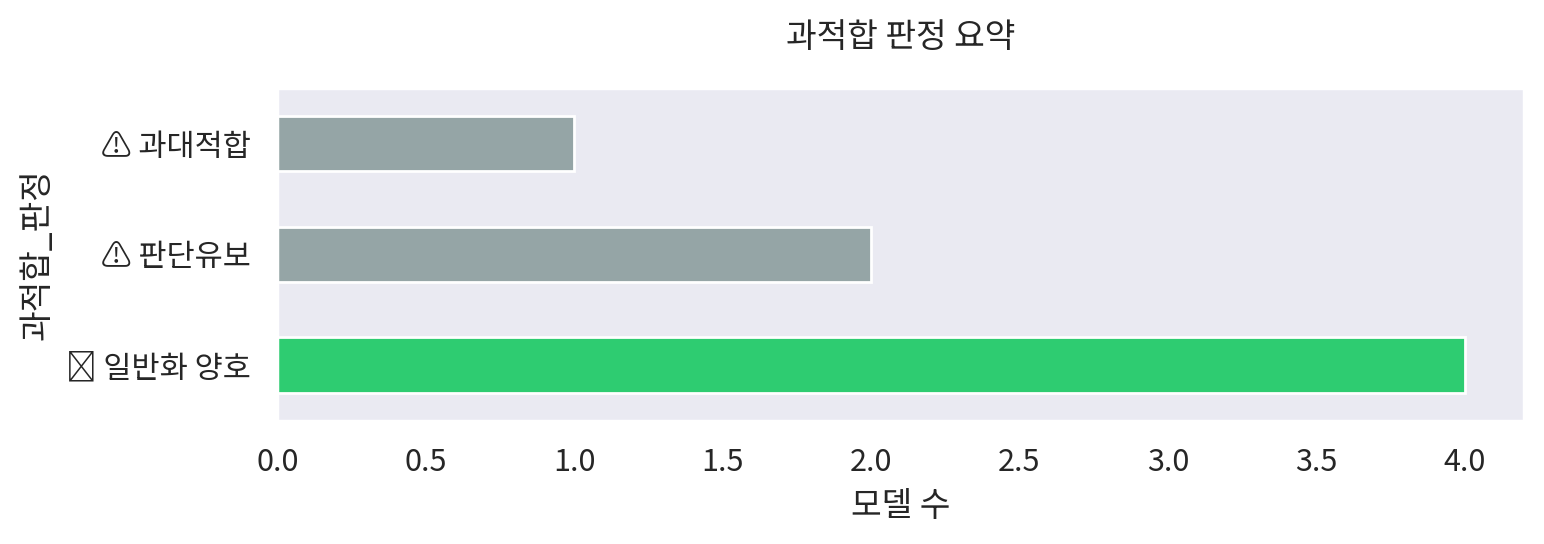

In [4]:
# 과적합 판정별 모델 수
status_counts = summary_perf["과적합_판정"].value_counts()
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
status_counts.plot(kind="barh", ax=ax, color=["#2ecc71" if "양호" in str(x) else "#95a5a6" for x in status_counts.index])
ax.set_xlabel("모델 수")
ax.set_title("과적합 판정 요약")
plt.tight_layout()
plt.show()

## 4. Feature Importance 수집 (트리: feature_importances_, 선형: coef_ 절대값)

In [5]:
def get_feature_importance(clf, name):
    """모델별로 feature importance 벡터 반환 (길이 = len(FEATURE_COLS))."""
    if hasattr(clf, "feature_importances_"):
        imp = clf.feature_importances_
    elif hasattr(clf, "coef_"):
        coef = clf.coef_
        imp = np.abs(coef[0]) if coef.ndim > 1 else np.abs(coef)
    else:
        return None
    if len(imp) != len(FEATURE_COLS):
        return None
    # 정규화 (합=1)
    imp = np.asarray(imp, dtype=float)
    if imp.sum() > 0:
        imp = imp / imp.sum()
    return imp

fi_list = []
for name, clf in models_loaded.items():
    imp = get_feature_importance(clf, name)
    if imp is not None:
        for feat, v in zip(FEATURE_COLS, imp):
            fi_list.append({"모델": name, "Feature": feat, "Importance": v})
    else:
        for feat in FEATURE_COLS:
            fi_list.append({"모델": name, "Feature": feat, "Importance": np.nan})

df_fi = pd.DataFrame(fi_list)
# 피벗: 모델 x Feature
fi_pivot = df_fi.pivot(index="모델", columns="Feature", values="Importance")
display(fi_pivot)

Feature,Region,log_Delicassen,log_Detergents_Paper,log_Fresh,log_Frozen,log_Grocery,log_Milk
모델,,,,,,,
CatBoost,0.020,0.036,0.567,0.047,0.069,0.160,0.101
DecisionTree,0.000,0.055,0.747,0.066,0.001,0.040,0.090
GradientBoosting,0.001,0.037,0.740,0.035,0.037,0.086,0.064
LogisticRegression,0.035,0.048,0.412,0.000,0.071,0.266,0.168
RandomForest,0.005,0.047,0.453,0.029,0.058,0.252,0.155
SGDClassifier,0.004,0.054,0.450,0.135,0.065,0.208,0.084
XGBoost,0.000,0.036,0.497,0.056,0.041,0.271,0.100


## 5. Feature Importance 결과 비교 시각화

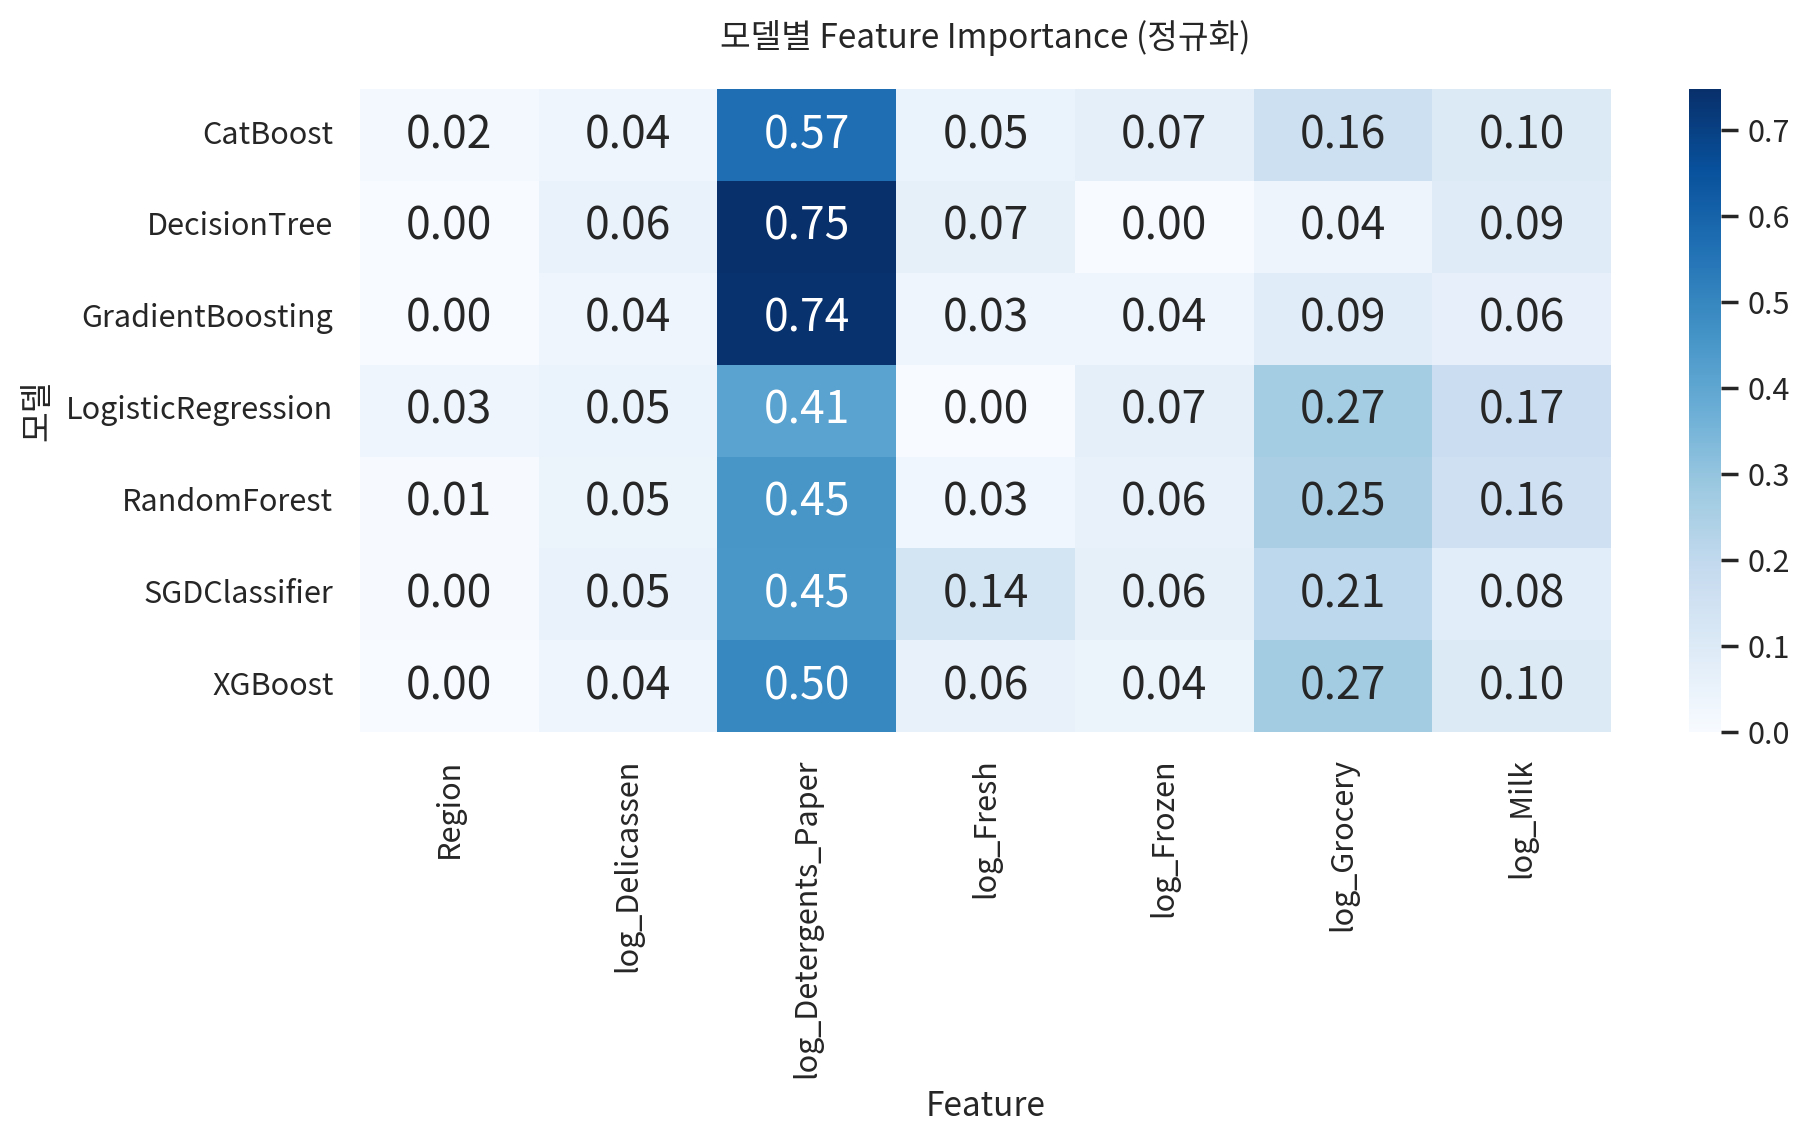

In [6]:
# Heatmap: 모델 x Feature
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.heatmap(fi_pivot.fillna(0), annot=True, fmt=".2f", cmap="Blues", ax=ax)
ax.set_title("모델별 Feature Importance (정규화)")
plt.tight_layout()
plt.show()

In [7]:
# 모델별 상위 3개 유의미 feature (정규화 importance 기준)
for model in fi_pivot.index:
    s = fi_pivot.loc[model].dropna().sort_values(ascending=False)
    top3 = s.head(3)
    print(f"{model}: {list(top3.index)}")

CatBoost: ['log_Detergents_Paper', 'log_Grocery', 'log_Milk']
DecisionTree: ['log_Detergents_Paper', 'log_Milk', 'log_Fresh']
GradientBoosting: ['log_Detergents_Paper', 'log_Grocery', 'log_Milk']
LogisticRegression: ['log_Detergents_Paper', 'log_Grocery', 'log_Milk']
RandomForest: ['log_Detergents_Paper', 'log_Grocery', 'log_Milk']
SGDClassifier: ['log_Detergents_Paper', 'log_Grocery', 'log_Fresh']
XGBoost: ['log_Detergents_Paper', 'log_Grocery', 'log_Milk']


## 6. SHAP 분석 (트리 모델 대표 1개: XGBoost)

- 트리 계열(XGB, RF, GB, DT, CatBoost)은 SHAP TreeExplainer 지원. 여기서는 **XGBoost** 1개에 대해 summary plot을 그려 Feature Importance와 해석을 비교합니다.

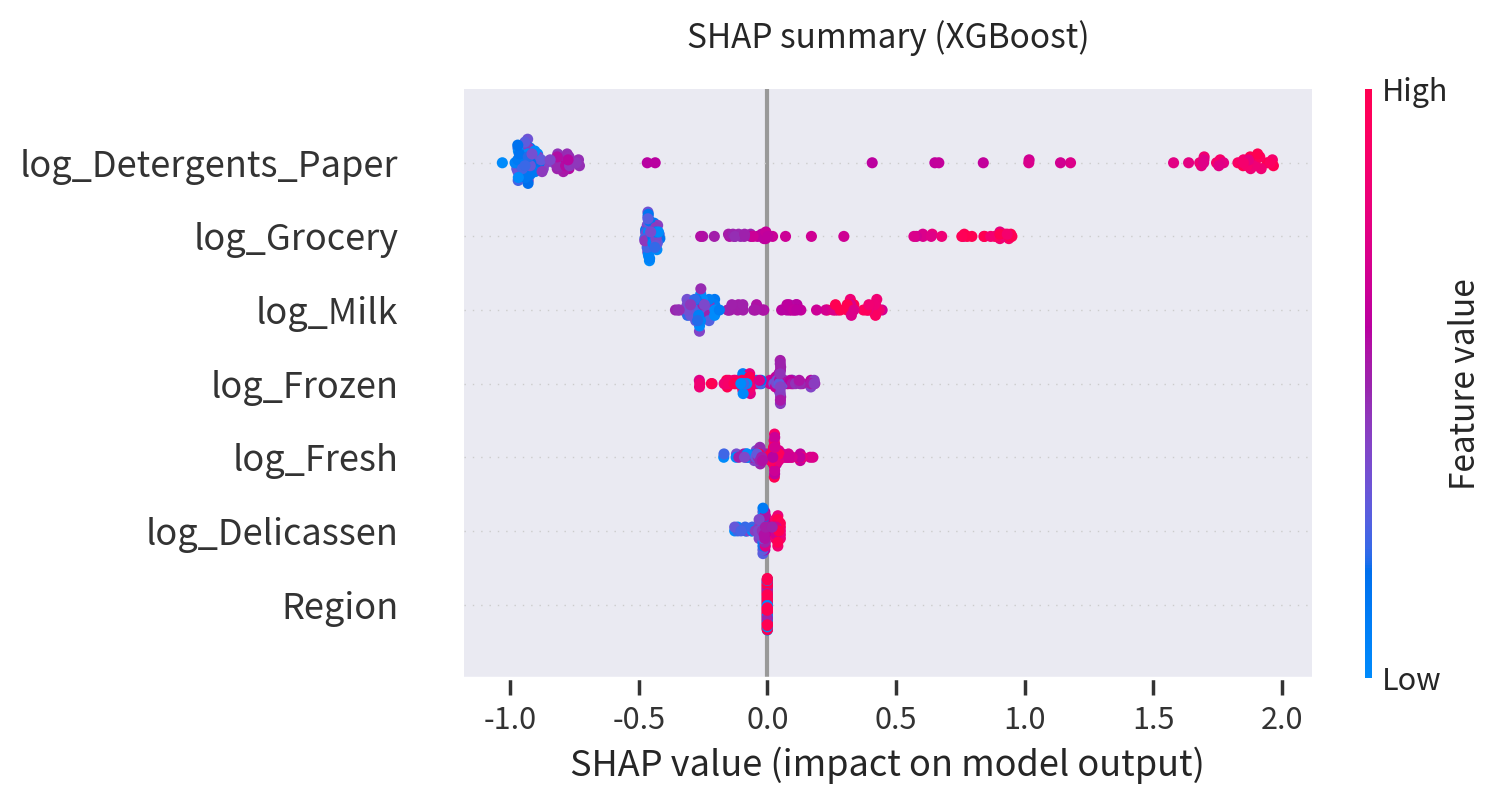

In [8]:
import shap

# XGBoost 모델로 SHAP (보통 해석·성능 균형이 좋음)
shap_name = "XGBoost"
if shap_name in models_loaded:
    clf_shap = models_loaded[shap_name]
    explainer = shap.TreeExplainer(clf_shap, X_train)
    shap_values = explainer.shap_values(X_test)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # 이진분류 시 양성 클래스
    shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=False)
    plt.title(f"SHAP summary ({shap_name})")
    plt.tight_layout()
    plt.show()
else:
    print(f"{shap_name} 모델이 없어 SHAP을 건너뜁니다.")

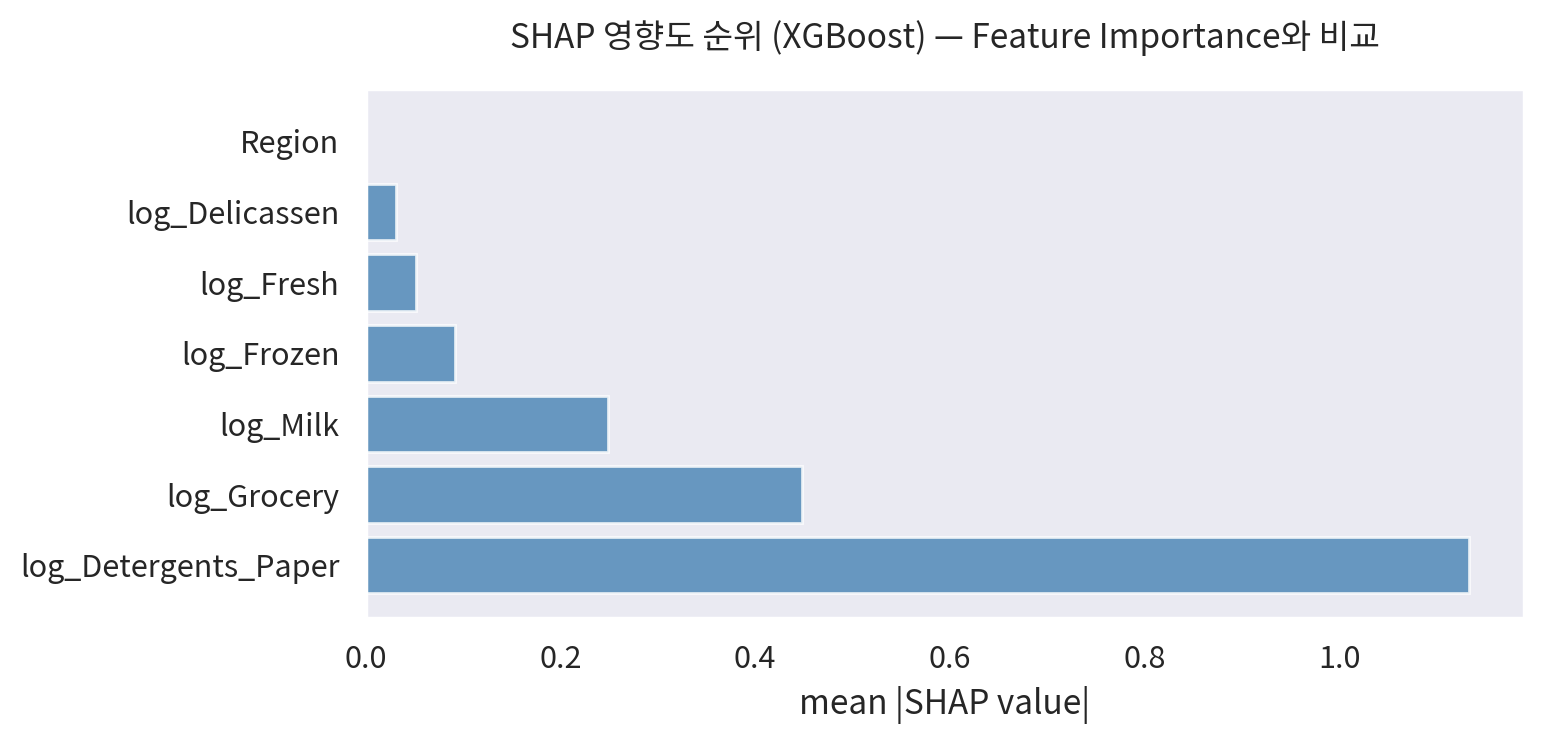

In [9]:
# SHAP 절대값 평균 = Feature 영향도 순위 (Feature Importance와 비교용)
if shap_name in models_loaded:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    idx = np.argsort(mean_abs_shap)[::-1]
    ax.barh([FEATURE_COLS[i] for i in idx], mean_abs_shap[idx], color="steelblue", alpha=0.8)
    ax.set_xlabel("mean |SHAP value|")
    ax.set_title(f"SHAP 영향도 순위 ({shap_name}) — Feature Importance와 비교")
    plt.tight_layout()
    plt.show()

## 7. 어떤 모델을 시각화·채택할지 추천

- **일반화 양호**이면서 **Test AUC**가 높고, **해석 가능성**(Feature Importance / SHAP)을 고려해 하나를 추천합니다.

In [10]:
# 일반화 양호한 모델 중 AUC 최고
ok = summary_perf[summary_perf["과적합_판정"].str.contains("일반화 양호", na=False)]
if len(ok) > 0:
    best = ok.loc[ok["AUC"].idxmax()]
    rec_name = best["모델"]
    print(f"추천 모델 (일반화 양호 + AUC 기준): {rec_name}")
    print(f"  Test AUC: {best['AUC']:.4f}, 과적합 판정: {best['과적합_판정']}")
else:
    # 양호한 게 없으면 AUC만으로 1등
    best = summary_perf.loc[summary_perf["AUC"].idxmax()]
    rec_name = best["모델"]
    print(f"일반화 양호 모델이 없어, AUC 최고 모델 추천: {rec_name}")
    print(f"  Test AUC: {best['AUC']:.4f}, 과적합 판정: {best['과적합_판정']}")

print("\n시각화/채택 권장:")
print("  - 대표 시각화: 위 추천 모델로 학습곡선·ROC·Feature Importance·SHAP을 한 노트북에서 유지하면 일관성 있음.")
print("  - 트리 모델(XGB, RF, CatBoost 등)은 SHAP으로 영향도 해석이 가능하므로, 해석이 중요하면 추천 모델이 트리일 때 SHAP을 사용.")

추천 모델 (일반화 양호 + AUC 기준): LogisticRegression
  Test AUC: 0.9539, 과적합 판정: ✅ 일반화 양호

시각화/채택 권장:
  - 대표 시각화: 위 추천 모델로 학습곡선·ROC·Feature Importance·SHAP을 한 노트북에서 유지하면 일관성 있음.
  - 트리 모델(XGB, RF, CatBoost 등)은 SHAP으로 영향도 해석이 가능하므로, 해석이 중요하면 추천 모델이 트리일 때 SHAP을 사용.
